<a href="https://colab.research.google.com/github/shreyasgowdac-319/ML-LAB/blob/main/1BM23CS319_Lab_8_AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving income - income.csv to income - income (2).csv
Accuracy with 10 estimators: 0.8182004299314157
Best number of estimators: 73
Best accuracy: 0.8339645818405159


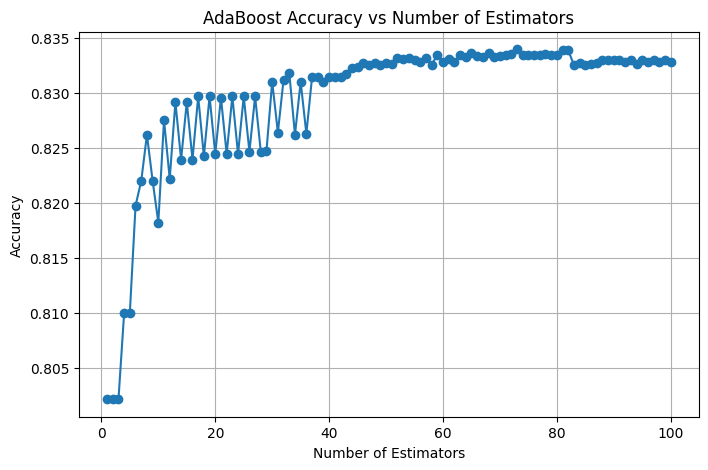

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
from google.colab import files
uploaded = files.upload()

data = pd.read_csv("income - income.csv")


target_col = data.columns[-1]


le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == "object":
        data[col] = le.fit_transform(data[col])


X = data.drop(target_col, axis=1)
y = data[target_col]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model_default = AdaBoostClassifier(n_estimators=10, random_state=42)
model_default.fit(X_train, y_train)
y_pred_default = model_default.predict(X_test)
default_score = accuracy_score(y_test, y_pred_default)
print("Accuracy with 10 estimators:", default_score)

n_values = range(1, 101)
scores = []

for n in n_values:
    model = AdaBoostClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

best_n = n_values[scores.index(max(scores))]
best_score = max(scores)

print("Best number of estimators:", best_n)
print("Best accuracy:", best_score)

plt.figure(figsize=(8,5))
plt.plot(n_values, scores, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost Accuracy vs Number of Estimators")
plt.grid(True)
plt.show()